   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa
(150, 4) (150,)
standardised values are
 [[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]
PCA(n_components=2) rofl
Explained variance(Eigen value) of Each Principal Component
 [2.93808505 0.9201649 ]
Explained variance ratio of each Principal component
 [0.76150718 0.23849282]
Cumulative variance ratio of Principal components
 [0.76150718 1.        ]
(150, 2)
Transformed data points(Principal Components)
 

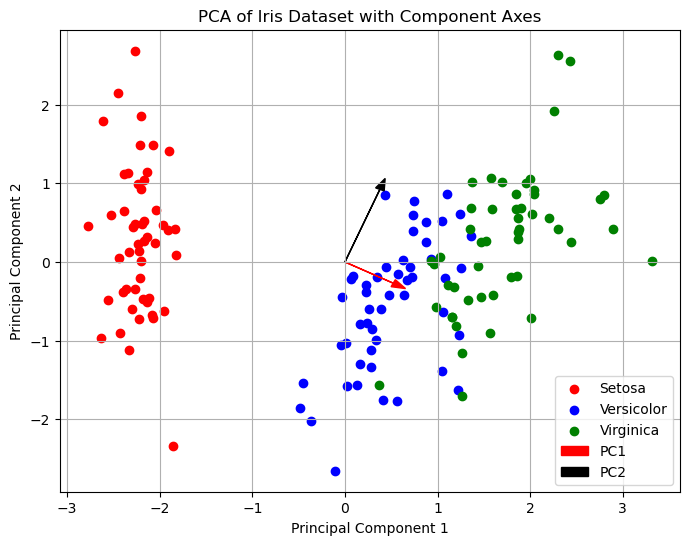

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv("iris_1.csv")
print(data[:5])

# Extract features and labels
X = data.iloc[:, 0:-1]
y = data.iloc[:, -1]
print(X.shape, y.shape)

# Standardizing the features
X = StandardScaler().fit_transform(X)  # using standard scalar (Z-score)
print(f'standardised values are\n', X[:5])

# initializing the pca
from sklearn import decomposition
pca1 = decomposition.PCA(n_components=2)
print(pca1)

pca_data = pca1.fit_transform(X)

print(f'Explained variance(Eigen value) of Each Principal Component\n', pca1.explained_variance_)

percentage_var = pca1.explained_variance_ / np.sum(pca1.explained_variance_)
cumulative_var = np.cumsum(percentage_var)

print(f'Explained variance ratio of each Principal component\n', percentage_var)
print(f'Cumulative variance ratio of Principal components\n', cumulative_var)

print(pca_data.shape)
print(f'Transformed data points(Principal Components)\n', pca_data[:5])

# Convert PCA output to a DataFrame
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['variety'] = y  # target labels

# Define colors for each species
target_colors = {'Setosa': 'red', 'Versicolor': 'blue', 'Virginica': 'green'}

# Plot PCA results
plt.figure(figsize=(8, 6))

for species, color1 in target_colors.items():
    subset = pca_df[pca_df['variety'] == species]
    plt.scatter(subset['PC1'], subset['PC2'], label=species, color=color1)

# Compute Eigenvectors
eigenvectors = pca1.components_
mean_x, mean_y = np.mean(pca_data, axis=0)
pc_colors = ['red', 'black']

# Plot PCA Component Lines
for i in range(2):  # Two principal components
    plt.arrow(mean_x, mean_y, eigenvectors[i, 0], eigenvectors[i, 1],
              color=pc_colors[i], head_width=0.1, label=f'PC{i+1}')

# Customize plot
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset with Component Axes')
plt.legend()
plt.grid(True)
plt.show()